In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# This is the object detection model I am using for the CV part of the project.
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.7 MB/s eta 0:00:00


In [4]:
# Importing necessary libraries
import os
import zipfile
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# This is the location of the dataset zip in Google Drive.
zip_path = "/content/drive/MyDrive/courtroom_project/courtroom-detection.yolov8.zip"
extract_path = "/content/courtroom_dataset"

In [6]:
# Remove any older extracted dataset folder so the notebook starts clean.
!rm -rf /content/courtroom_dataset
!mkdir -p /content/courtroom_dataset

In [7]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")

Unzipped successfully


In [8]:
#This is to confirm whether the export contains only train or also valid and test folders.
!find /content/courtroom_dataset -maxdepth 2 -type d

/content/courtroom_dataset
/content/courtroom_dataset/train
/content/courtroom_dataset/train/labels
/content/courtroom_dataset/train/images


In [9]:
# This file shows the class names from the dataset export.
!cat /content/courtroom_dataset/train/_darknet.labels

cat: /content/courtroom_dataset/train/_darknet.labels: No such file or directory


In [10]:
!ls /content

courtroom_dataset  drive  sample_data


In [11]:
!find /content/courtroom_dataset -maxdepth 3

/content/courtroom_dataset
/content/courtroom_dataset/README.roboflow.txt
/content/courtroom_dataset/train
/content/courtroom_dataset/train/labels
/content/courtroom_dataset/train/labels/57_jpg.rf.MiLt9whsfygcsVfajJ4J.txt
/content/courtroom_dataset/train/labels/93_jpg.rf.hPQZfcbNNmW07XsIGFsO.txt
/content/courtroom_dataset/train/labels/32_webp.rf.X6ydgkNnjAGvd85NjnOm.txt
/content/courtroom_dataset/train/labels/14_jpg.rf.XFPG0TnsOS3QCL28OS3D.txt
/content/courtroom_dataset/train/labels/19_webp.rf.aEKjZUL4GiYQnVfIq7ER.txt
/content/courtroom_dataset/train/labels/2_jpg.rf.r3c71eZiPa6unSNN5Iej.txt
/content/courtroom_dataset/train/labels/13_jpg.rf.ZclUYYXJIy2XMF0jWDhB.txt
/content/courtroom_dataset/train/labels/25_webp.rf.ARTULzPUxLjlXs56zHvq.txt
/content/courtroom_dataset/train/labels/53_jpg.rf.Sg1YrkgBhqCB7e3EITZ9.txt
/content/courtroom_dataset/train/labels/91_jpg.rf.Aev4bCkZAyT1Zbl0Sruj.txt
/content/courtroom_dataset/train/labels/65_webp.rf.eXEo50pP4BX2y3nIFrxq.txt
/content/courtroom_datase

In [12]:
!ls "/content/drive/MyDrive/courtroom_project"

 best.pt			  final_with_audio.mp4	'testing 2.mp4'
 courtroom-detection.yolov8.zip   outputs		 train
 data				  testing
 final_with_audio_fixed.mp4	 'testing 1.mp4'


In [13]:
!unzip -l "/content/drive/MyDrive/courtroom_project/courtroom-detection.yolov8.zip"

Archive:  /content/drive/MyDrive/courtroom_project/courtroom-detection.yolov8.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   334818  2026-04-23 03:20   train/images/91_jpg.rf.Aev4bCkZAyT1Zbl0Sruj.jpg
    67204  2026-04-23 03:20   train/images/78_webp.rf.5SkoZ26tTeQu4podCvBH.webp
   449674  2026-04-23 03:20   train/images/90_jpg.rf.D0whzjuoqvKWTVNg0KAs.jpg
   124291  2026-04-23 03:20   train/images/93_jpg.rf.hPQZfcbNNmW07XsIGFsO.jpg
   616206  2026-04-23 03:20   train/images/82_webp.rf.J91lYQJndWT7x64pUvpg.webp
    79364  2026-04-23 03:20   train/images/74_webp.rf.5CZWaWcCku6QVl5dXySq.webp
   223160  2026-04-23 03:20   train/images/55_jpg.rf.JgM1aqowkj2Sgo5qeAAf.jpg
   102378  2026-04-23 03:20   train/images/67_webp.rf.J49929SkbgvmZCyA0yNZ.webp
   344272  2026-04-23 03:20   train/images/75_jpg.rf.1zi9Z4l9kFKigUE1O6Y2.jpg
    16876  2026-04-23 03:20   train/images/51_webp.rf.KMcI5TnfNWKFLHlHUxpy.webp
   209694  2026-04-23 03:20   train/images/56_jpg.rf.nv1kJ

In [14]:
!rm -rf /content/courtroom_dataset
!mkdir /content/courtroom_dataset

!unzip "/content/drive/MyDrive/courtroom_project/courtroom-detection.yolov8.zip" -d /content/courtroom_dataset

Archive:  /content/drive/MyDrive/courtroom_project/courtroom-detection.yolov8.zip
 extracting: /content/courtroom_dataset/train/images/91_jpg.rf.Aev4bCkZAyT1Zbl0Sruj.jpg  
 extracting: /content/courtroom_dataset/train/images/78_webp.rf.5SkoZ26tTeQu4podCvBH.webp  
 extracting: /content/courtroom_dataset/train/images/90_jpg.rf.D0whzjuoqvKWTVNg0KAs.jpg  
 extracting: /content/courtroom_dataset/train/images/93_jpg.rf.hPQZfcbNNmW07XsIGFsO.jpg  
 extracting: /content/courtroom_dataset/train/images/82_webp.rf.J91lYQJndWT7x64pUvpg.webp  
 extracting: /content/courtroom_dataset/train/images/74_webp.rf.5CZWaWcCku6QVl5dXySq.webp  
 extracting: /content/courtroom_dataset/train/images/55_jpg.rf.JgM1aqowkj2Sgo5qeAAf.jpg  
 extracting: /content/courtroom_dataset/train/images/67_webp.rf.J49929SkbgvmZCyA0yNZ.webp  
 extracting: /content/courtroom_dataset/train/images/75_jpg.rf.1zi9Z4l9kFKigUE1O6Y2.jpg  
 extracting: /content/courtroom_dataset/train/images/51_webp.rf.KMcI5TnfNWKFLHlHUxpy.webp  
 extract

In [15]:
# Print the exported YOLOv8 configuration file to verify the dataset paths and class names before training.
!cat /content/courtroom_dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['flag', 'judge bench', 'microphone', 'person']

roboflow:
  workspace: laritzas-workspace
  project: laritzas-workspace
  version: dataset
  license: Private
  url: https://app.roboflow.com/laritzas-workspace/laritzas-workspace/dataset

In [16]:
# Show the top-level dataset folders so I can verify which splits exist.
!find /content/courtroom_dataset -maxdepth 2 -type d

/content/courtroom_dataset
/content/courtroom_dataset/train
/content/courtroom_dataset/train/labels
/content/courtroom_dataset/train/images


In [17]:
%%writefile /content/courtroom_dataset/data.yaml
# YOLO dataset configuration file
# This dataset only contains a train split, so train/val/test
# are all pointed to the same images folder for now.
# This is not ideal for final evaluation, but it allows the
# model to train correctly on the available data.

path: /content/courtroom_dataset
train: train/images
val: train/images
test: train/images

names:
  0: flag
  1: judge bench
  2: microphone
  3: person

Overwriting /content/courtroom_dataset/data.yaml


In [18]:
# Remove old cache files so YOLO reads the corrected paths again.
!rm -f /content/courtroom_dataset/train.cache
!rm -f /content/courtroom_dataset/valid.cache
!rm -f /content/courtroom_dataset/test.cache

In [19]:
# Print the corrected YAML to make sure the paths and class names are correct.
!cat /content/courtroom_dataset/data.yaml

# YOLO dataset configuration file
# This dataset only contains a train split, so train/val/test
# are all pointed to the same images folder for now.
# This is not ideal for final evaluation, but it allows the
# model to train correctly on the available data.

path: /content/courtroom_dataset
train: train/images
val: train/images
test: train/images

names:
  0: flag
  1: judge bench
  2: microphone
  3: person


In [20]:
# Load a small pretrained YOLOv8 model.
# I am fine-tuning a pretrained model instead of training from scratch
# because that is more realistic for the project timeframe.
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

# Train the model on the corrected dataset configuration.
# epochs controls how many passes the model makes over the dataset.
# imgsz sets the training image size.
# batch controls how many images are processed at one time.
model.train(
    data="/content/courtroom_dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/courtroom_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cd037174bc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [21]:
!cat /content/courtroom_dataset/data.yaml

# YOLO dataset configuration file
# This dataset only contains a train split, so train/val/test
# are all pointed to the same images folder for now.
# This is not ideal for final evaluation, but it allows the
# model to train correctly on the available data.

path: /content/courtroom_dataset
train: train/images
val: train/images
test: train/images

names:
  0: flag
  1: judge bench
  2: microphone
  3: person


In [22]:
data="/content/courtroom_dataset/data.yaml"

In [23]:
%%writefile /content/courtroom_dataset/data.yaml
path: /content/courtroom_dataset
train: train/images
val: train/images
test: train/images

names:
  0: flag
  1: judge bench
  2: microphone
  3: person

Overwriting /content/courtroom_dataset/data.yaml


In [24]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/courtroom_dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/courtroom_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cd0444bcdd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [25]:
!cp /content/runs/detect/train/weights/best.pt /content/drive/MyDrive/courtroom_project/best.pt

In [26]:
!ls runs/detect/train

args.yaml			 results.csv	     val_batch0_labels.jpg
BoxF1_curve.png			 results.png	     val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg    val_batch1_labels.jpg
BoxPR_curve.png			 train_batch160.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch161.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch162.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg    weights
labels.jpg			 train_batch2.jpg


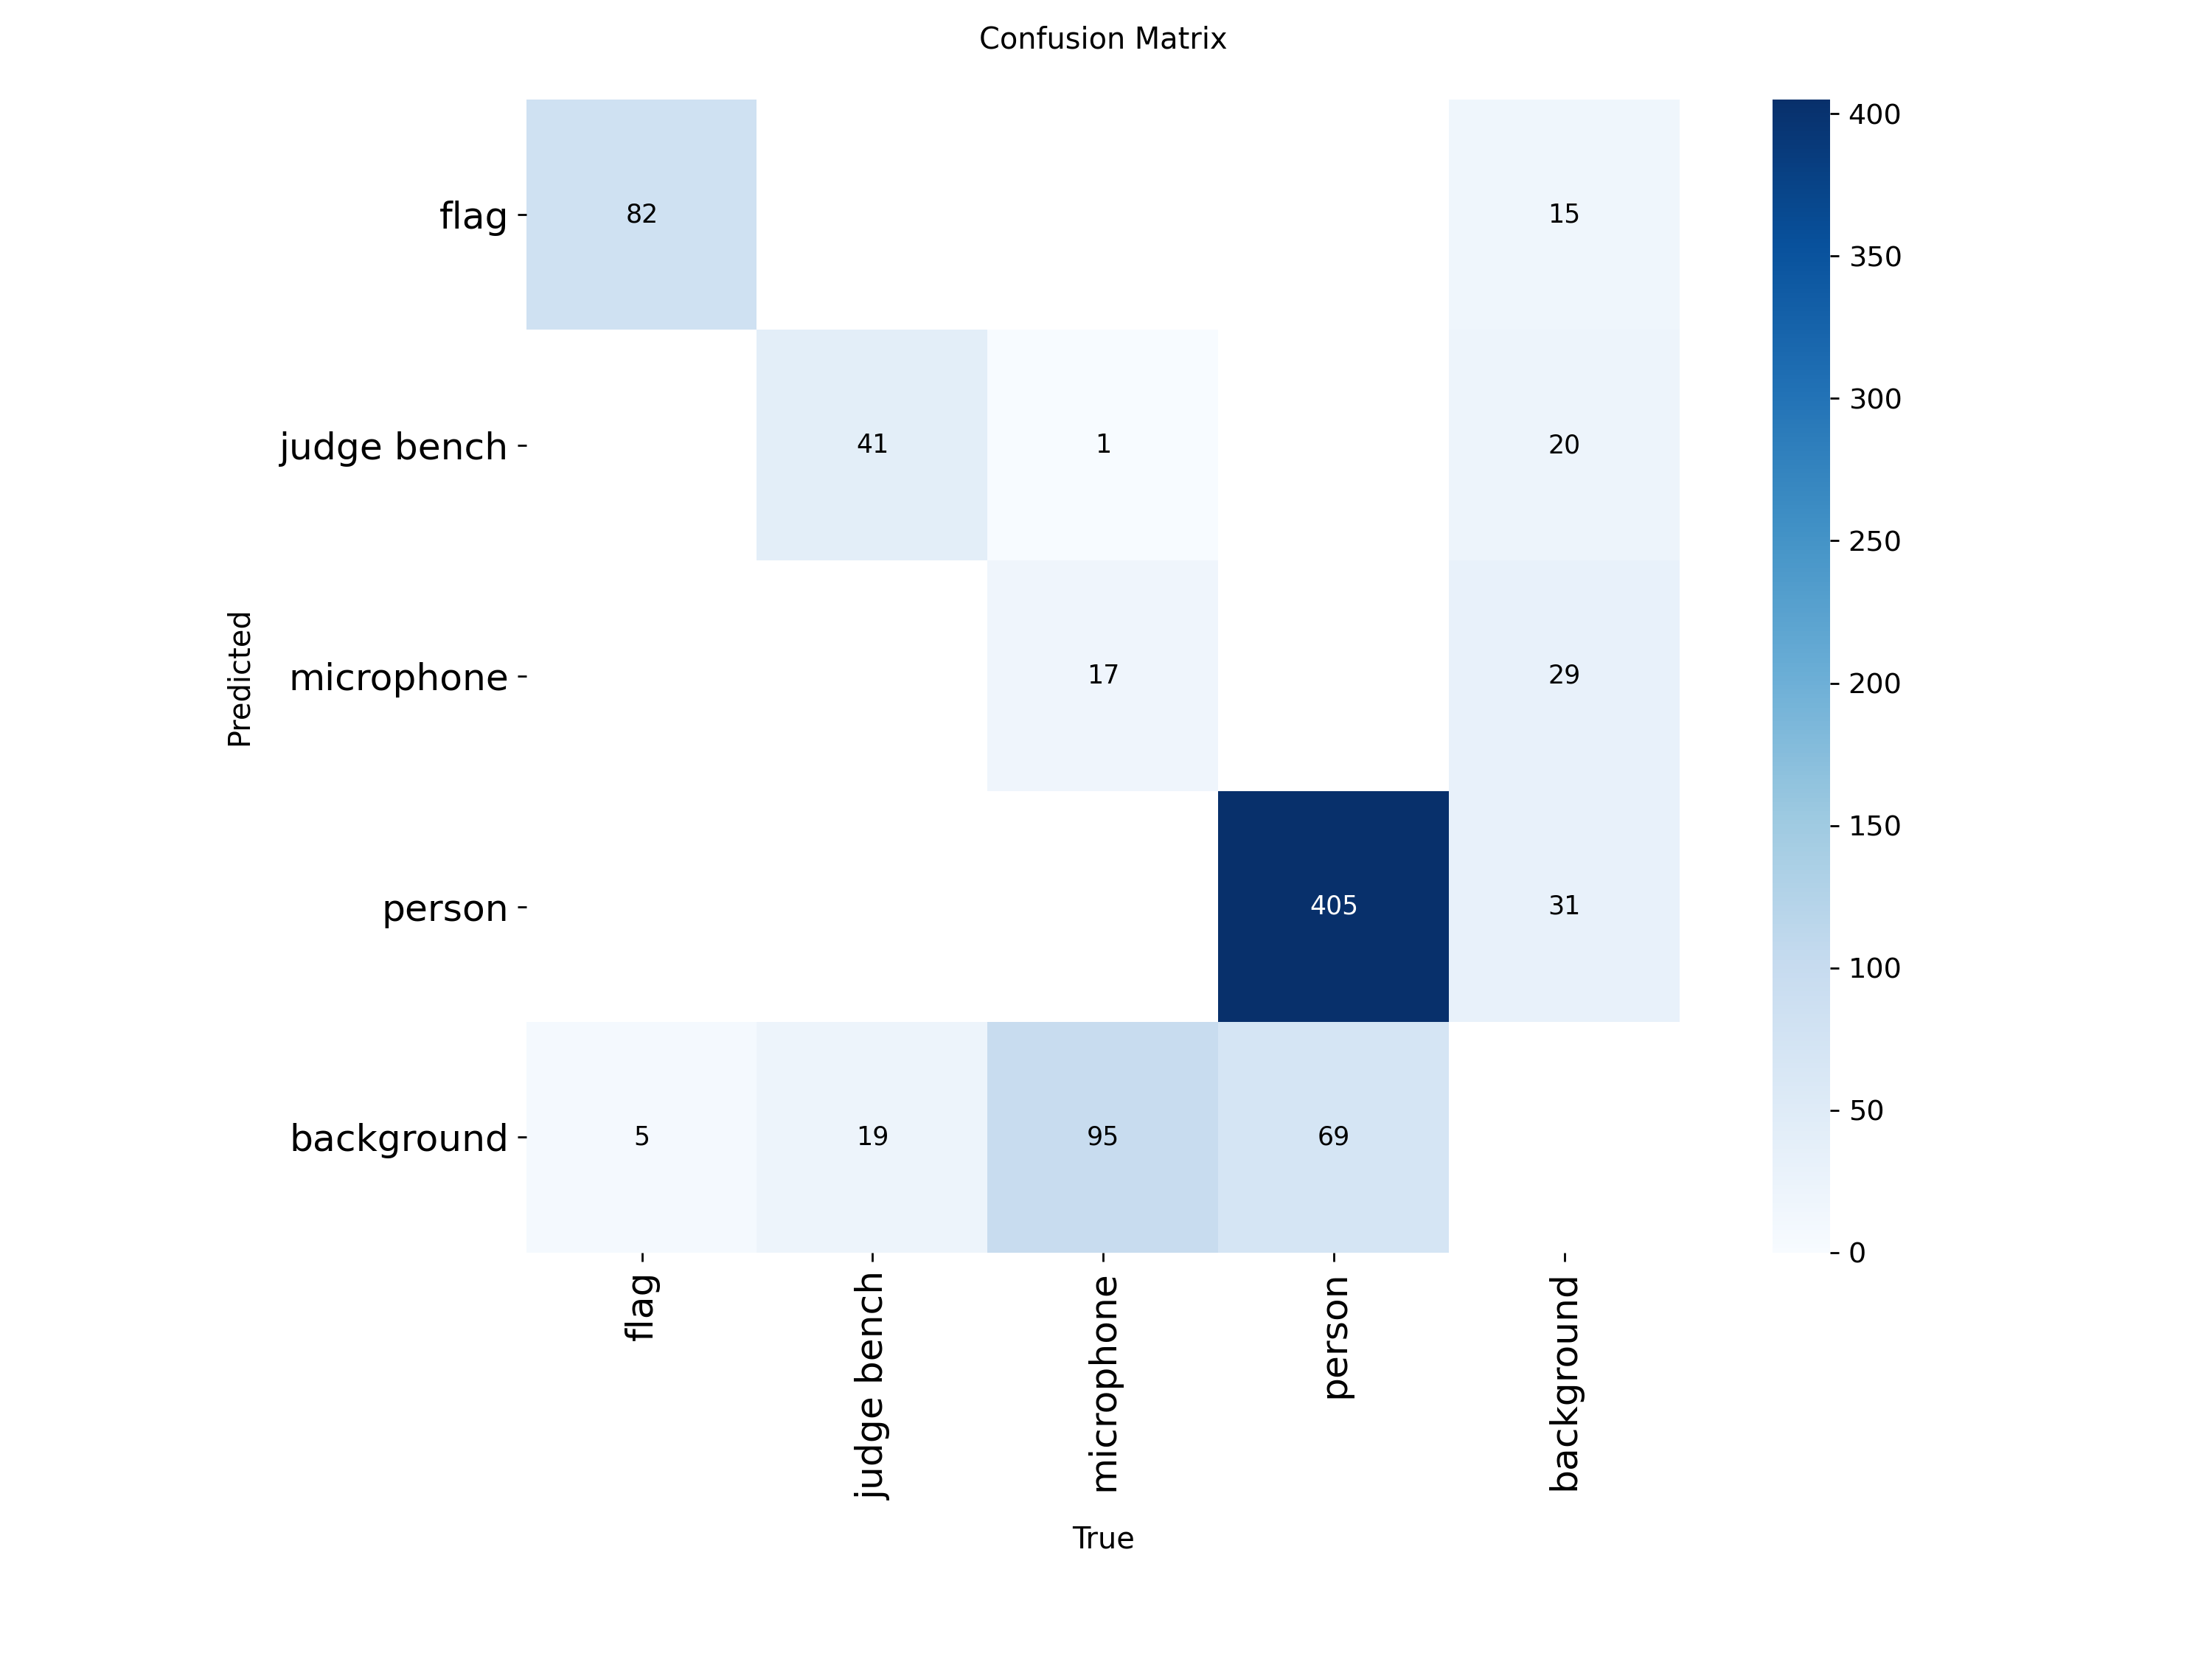

In [27]:
from IPython.display import Image, display

display(Image(filename='runs/detect/train/confusion_matrix.png'))

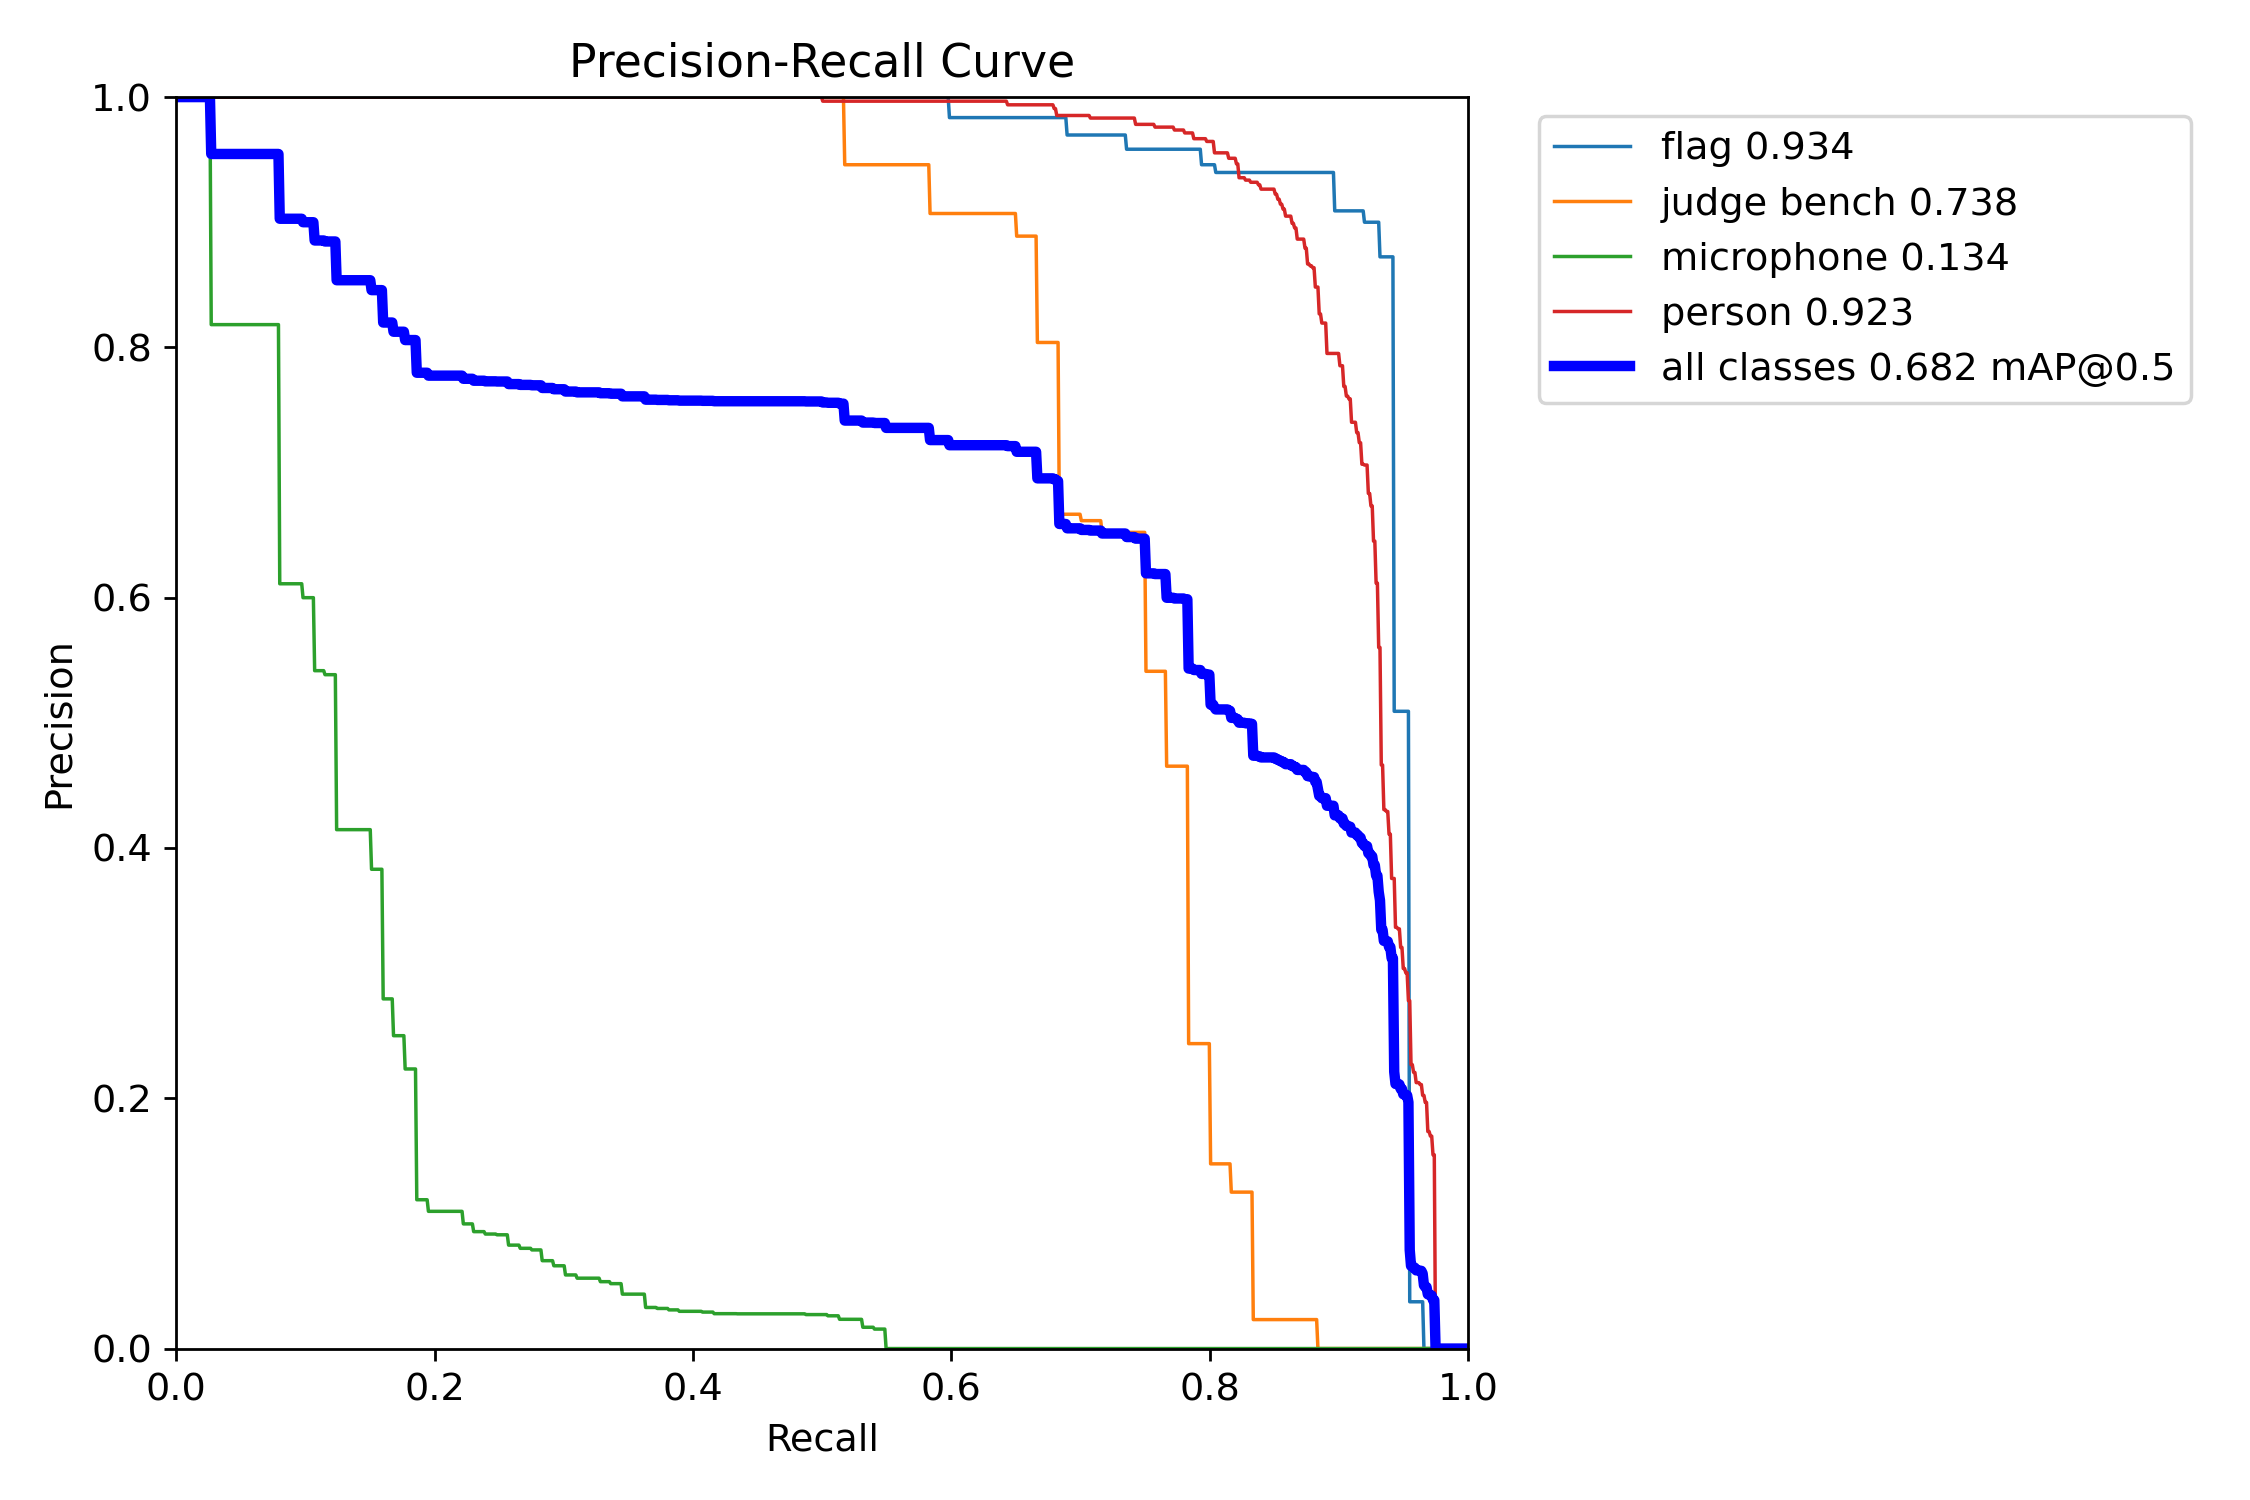

In [28]:
from IPython.display import Image, display

display(Image(filename='runs/detect/train/BoxPR_curve.png'))

In [29]:
!ls runs/detect/predict

ls: cannot access 'runs/detect/predict': No such file or directory


In [30]:
import pandas as pd

df = pd.read_csv("runs/detect/train/results.csv")
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,81.8368,0.94878,1.20372,1.06122,0.72500,0.61910,0.67117,0.51859,0.80397,0.99479,0.97415,0.000219,0.000219,0.000219
26,27,85.6372,0.91510,1.23573,1.04227,0.74002,0.62946,0.67444,0.52643,0.80068,0.98359,0.97324,0.000178,0.000178,0.000178
27,28,88.9045,0.94031,1.29214,1.04210,0.74049,0.63395,0.67725,0.52754,0.78711,0.96618,0.96709,0.000136,0.000136,0.000136
28,29,91.3202,0.89662,1.23046,1.02895,0.78747,0.62306,0.68040,0.53346,0.77621,0.95221,0.96302,0.000095,0.000095,0.000095
29,30,93.9180,0.85037,1.14894,1.02203,0.79759,0.63098,0.68230,0.53882,0.76431,0.93856,0.95918,0.000054,0.000054,0.000054
